---
---
---
<a name="COMPILE"></a>
## C) Make `torch.compile` work without graph breaks for QLoRA [Difficulty: Easy to Medium] [Max points: 9]

1. Goal: Write a single Python script like task B), except the goal is to `torch.compile` all modules if possible.

2. There must NOT be graph breaks, and excessive re-compilations should not be seen.

3. You should have say max 30 compilations. Over 60 is definitely wrong.

4. The loss must match with the non compiled module.

5. Utilize patching as much as possible.

6. Think about which areas might need disabling for compilation. Think about regional compilation. How do we compile sections efficiently?

7. Log memory / VRAM usage, and monitor speedups as well.

8. Must work for QLoRA.

We provided a script below, and showcased how to detect if graph breaks are seen. We also torch compiled the MLP for Llama:

### Marking Criteria for C) Max points = 9
```python
if attemped_C:
    C_score = 0
    if uses_flex_attention:
        if dynamic_sequence_length_works: C_score += 3
        else: C_score += 1
    if no_torch_compile_BnB: C_score -= 2
    elif use_part_A: C_score += 1
    elif torch_compile_BnB: C_score += 1

    if attention_compiled:
        if excessive_recompilation: C_score -= 3
        else: C_score += 2
    if mlp_compiled:
        if excessive_recompilation: C_score -= 3
        C_score += 1

    if not loss_compiled: C_score -= 1
    if not layernorms_compiled: C_score -= 3

    if max_autotune_triton_matmul:
        if excessive_recompilation: C_score -= 2
        else: C_score += 2
    
    final_score += C_score
else:
    final_score -= 1
```

In [1]:
# Code to install Unsloth, Triton, Torch etc
# %%capture
# !pip install --no-deps bitsandbytes accelerate xformers==0.0.29 peft trl triton
# !pip install --no-deps cut_cross_entropy unsloth_zoo
# !pip install sentencepiece protobuf datasets huggingface_hub hf_transfer
# !pip install --no-deps unsloth

In [2]:
# Helpful functions used through the entire notebook
import torch
import torch.nn as nn
from transformers import set_seed
import time
import inspect
import os

major_version, minor_version = torch.cuda.get_device_capability()
HAS_BFLOAT16 = major_version >= 8
from inspect import currentframe as _C, getframeinfo

_F = lambda c: getframeinfo(c).lineno  # Gets line number
WARN = lambda x: print(f"\033[31m{x}\033[0m")  # Red colored warnings


# https://stackoverflow.com/questions/18425225/getting-the-name-of-a-variable-as-a-string
def NAME(var):
    callers_local_vars = inspect.currentframe().f_back.f_locals.items()
    names = [var_name for var_name, var_val in callers_local_vars if var_val is var]
    return names[0] if len(names) != 0 else ""


def assert_same(x, y, line, dtype):
    assert x.dtype == dtype
    try:
        torch.testing.assert_close(x, y, check_stride=True)
    except Exception as error:
        raise RuntimeError(
            f"Failed allclose at line [{line}]: {NAME(x)}, {NAME(y)}\n{str(error)}"
        )


os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

In [3]:
torch_compile_options = {
    "epilogue_fusion": True,
    "max_autotune": True,
    "shape_padding": True,
    "trace.enabled": True,
    "triton.cudagraphs": False,
}

TOGGLE_ORIGINAL = True


@torch.compile(fullgraph=False, dynamic=True, options=torch_compile_options)
def compiled_llama_mlp(self, x):
    down_proj = self.down_proj(self.act_fn(self.gate_proj(x)) * self.up_proj(x))
    return down_proj

import transformers.models.llama.modeling_llama

transformers.models.llama.modeling_llama.LlamaMLP.forward = compiled_llama_mlp

In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig, TaskType

os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = (
    "expandable_segments:True," "roundup_power2_divisions:[32:256,64:128,256:64,>:32]"
)

max_seq_length = 1024
torch.set_default_dtype(torch.float16)
model_name = "unsloth/Llama-3.2-1B-Instruct-bnb-4bit"
dtype = torch.float16
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=dtype,
)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    attn_implementation="sdpa",
    quantization_config=bnb_config,
)
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.padding_side = "right"

lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_dropout=0,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

# Get LoRA and setup model
model = get_peft_model(model, lora_config)
with torch.no_grad():
    for name, param in model.named_parameters():
        if ".lora_A." in name or ".lora_B." in name:
            param.requires_grad_(True)
        else:
            param.requires_grad_(False)

# Currently GC will cause torch.compile to be disabled, so disable it
# model.gradient_checkpointing_enable()
model.enable_input_require_grads()

# Get dataset
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig

url = "https://huggingface.co/datasets/laion/OIG/resolve/main/unified_chip2.jsonl"
dataset = load_dataset("json", data_files={"train": url}, split="train[:10%]")

/opt/conda/lib/python3.12/site-packages/transformers/quantizers/auto.py:212: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


Now that the model has been loaded, we inspect, and then patch and compile parts of the model.

In [5]:
# Must show all graph breaks are not seen with torch.compile
import os

os.environ["TORCHDYNAMO_VERBOSE"] = "1"
os.environ["TORCHINDUCTOR_FORCE_DISABLE_CACHES"] = "1"
os.environ["TORCHINDUCTOR_COMPILE_THREADS"] = "1"

import logging

torch._inductor.config.debug = True
torch._logging.set_logs(
    dynamo=logging.WARN,
    inductor=logging.WARN,
    graph_breaks=True,
    recompiles=True,
    recompiles_verbose=True,
    compiled_autograd_verbose=True,
    # aot_joint_graph = True, # Enable for more logs
    # aot_graphs = True,
)
torch._dynamo.config.verbose = True
torch._dynamo.config.suppress_errors = False

In [6]:
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    processing_class=tokenizer,
    args=SFTConfig(
        per_device_train_batch_size=1,
        gradient_accumulation_steps=2,
        warmup_steps=1,
        max_steps=10,
        logging_steps=1,
        output_dir="outputs",
        seed=3407,
        max_seq_length=max_seq_length,
        fp16=model.get_input_embeddings().weight.dtype == torch.float16,
        bf16=model.get_input_embeddings().weight.dtype == torch.bfloat16,
        report_to="none",  # For W&B
        dataset_num_proc=4,
    ),
)
trainer.train()

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
V0413 00:11:51.771000 80041 site-packages/torch/_dynamo/symbolic_convert.py:435] [0/0] [__graph_breaks] Graph break in user code at /opt/conda/lib/python3.12/site-packages/bitsandbytes/nn/modules.py:484
V0413 00:11:51.771000 80041 site-packages/torch/_dynamo/symbolic_convert.py:435] [0/0] [__graph_breaks] Reason: Unsupported: call_method UserDefinedObjectVariable(Params4bit) t [] {}
V0413 00:11:51.771000 80041 site-packages/torch/_dynamo/symbolic_convert.py:435] [0/0] [__graph_breaks] User code traceback:
V0413 00:11:51.771000 80041 site-packages/torch/_dynamo/symbolic_convert.py:435] [0/0] [__graph_breaks]   File "/tmp/ipykernel_80041/2678255783.py", line 14, in compiled_llama_mlp
V0413 00:11:51.771000 80041 site-packages/torch/_dy

Step,Training Loss
1,1.519600
2,2.393900
3,2.500900
4,3.531600
5,2.136900
6,2.974900
7,2.244200
8,1.623900
9,2.218300
10,2.675800


TrainOutput(global_step=10, training_loss=2.3819888472557067, metrics={'train_runtime': 15.7992, 'train_samples_per_second': 1.266, 'train_steps_per_second': 0.633, 'total_flos': 10592155496448.0, 'train_loss': 2.3819888472557067})

In [7]:
train_history = trainer.state.log_history
original_losses = []
original_steps = []

for log in train_history:
    if "loss" in log:
        original_losses.append(log["loss"])
        original_steps.append(log["step"])
original_losses

[1.5196,
 2.3939,
 2.5009,
 3.5316,
 2.1369,
 2.9749,
 2.2442,
 1.6239,
 2.2183,
 2.6758]

In [20]:
del model
import gc

gc.collect()
torch.cuda.empty_cache()

In [21]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig, TaskType

os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = (
    "expandable_segments:True," "roundup_power2_divisions:[32:256,64:128,256:64,>:32]"
)

max_seq_length = 1024
torch.set_default_dtype(torch.float16)
model_name = "unsloth/Llama-3.2-1B-Instruct-bnb-4bit"
dtype = torch.float16
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=dtype,
)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    attn_implementation="sdpa",
    quantization_config=bnb_config,
)
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.padding_side = "right"

lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_dropout=0,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

# Get LoRA and setup model
model = get_peft_model(model, lora_config)
with torch.no_grad():
    for name, param in model.named_parameters():
        if ".lora_A." in name or ".lora_B." in name:
            param.requires_grad_(True)
        else:
            param.requires_grad_(False)

# Currently GC will cause torch.compile to be disabled, so disable it
# model.gradient_checkpointing_enable()
model.enable_input_require_grads()

# Get dataset
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig

url = "https://huggingface.co/datasets/laion/OIG/resolve/main/unified_chip2.jsonl"
dataset = load_dataset("json", data_files={"train": url}, split="train[:10%]")

/opt/conda/lib/python3.12/site-packages/transformers/quantizers/auto.py:212: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


We grab our dequantization kernel from A, which we'll need to fix the biggest issue: the Linear4bit hidden layers.

In [22]:
import triton 
import triton.language as tl


@triton.jit
def gather_nf4_code(code_index, code_ptr):
    """In newer versions of triton, we attempt to use gather here on the code values.
        But since that's not available, we use this instead.
    """
    return tl.load(code_ptr + code_index, mask=code_index<16, eviction_policy="evict_last")


@triton.autotune(
    configs=[
        # triton.Config({'BLOCK_SIZE': 32}),
        # triton.Config({'BLOCK_SIZE': 64}),
        triton.Config({'BLOCK_SIZE': 128}),
        # triton.Config({'BLOCK_SIZE': 256}),
    ],
    key=['total_elements'],
)
@triton.jit()
def _your_dequantize_nf4_kernel(
    weight_ptr,  # [uint8]  Quantized weights, 1 byte => 2 NF4 elements
    absmax_ptr,  # [int]  One int "index" per element
    absmax2_ptr,  # [float]  One absmax2 per block
    code_ptr,  # [float]  NF4 code lookup
    code2_ptr,  # [float]  Absmax code lookup
    offset_ptr,  # [float]  Offset to add after absmax is decoded
    out_ptr,  # [float]  Final dequantized output
    weight_blocksize: tl.constexpr,  # [int]   Number of elements in a weight block
    absmax_blocksize: tl.constexpr, # [int]   Number of elements in a absmax block
    total_elements,  # [int]   Number of actual float elements to reconstruct
    BLOCK_SIZE: tl.constexpr,
):
    # context; we adopt the pov of a quantized byte, which corresponds to 2 elems
    pid = tl.program_id(0)
    start = pid * BLOCK_SIZE
    index = start + tl.arange(0, BLOCK_SIZE)

    offset = tl.load(offset_ptr, eviction_policy="evict_last")

    # the block index of the byte
    # weight_block_index = index // (weight_blocksize // 2) # naive approach
    # now we end up with a vector like (0, 0, ... 0, 0, 1, 1, ...)
    # we can shrink this by applying a stride of weight_blocksize // 2 so that our vector looks like (0, 1, 2, ...)
    weight_block_index = start // (weight_blocksize // 2) + tl.arange(0, BLOCK_SIZE // (weight_blocksize // 2))
    absmax_block_index = weight_block_index // absmax_blocksize # the block index of the absmax

    # mask calculations
    byte_index_mask = index < (total_elements // 2)
    weight_block_mask = weight_block_index < (total_elements // weight_blocksize) 
    abs_block_mask = absmax_block_index < (total_elements // weight_blocksize // absmax_blocksize)

    # compute absmax for the block these weights belong to:
    absmax1_code = tl.load(absmax_ptr + weight_block_index, mask=weight_block_mask, eviction_policy="evict_last")
    absmax1_code = absmax1_code.to(tl.int16) # this is necessary
    
    # reading values from code is likely a very slow process due to lack of contiguity
    absmax1_val = tl.load(code2_ptr + absmax1_code, mask=(absmax1_code < 256))
    absmax2_val = tl.load(absmax2_ptr + absmax_block_index, mask=abs_block_mask, eviction_policy="evict_last")
    
    absmax = tl.fma(absmax1_val, absmax2_val, offset)

    # lookup each weight bit
    byte = tl.load(weight_ptr + index, mask=byte_index_mask, eviction_policy="evict_first")

    code_index2 = byte & 0x0F  # Lower 4 bits
    code_index1 = (byte >> 4) & 0x0F  # Upper 4 bits

    code_index_range = tl.arange(0, 16) # 16 possible values
    _ = tl.load(code_ptr + code_index_range, eviction_policy="evict_last") # pull code contiguously into cache

    # interleaving the values here, prior to matmul, causes a slight decrease in average perf on T4 (poorer lower bound)
    # weight = dequantize_nf4_code(tl.interleave(code_index1, code_index2)).reshape(BLOCK_SIZE // (weight_blocksize // 2), weight_blocksize) * absmax[:, None]

    # Dequantize both 4-bit values
    weight1 = gather_nf4_code(code_index1, code_ptr).reshape(BLOCK_SIZE // (weight_blocksize // 2), weight_blocksize // 2) * absmax[:, None]
    weight2 = gather_nf4_code(code_index2, code_ptr).reshape(BLOCK_SIZE // (weight_blocksize // 2), weight_blocksize // 2) * absmax[:, None]

    # combine to prevent a non-contiguous write because of writing to even/odd indexes
    weight_index = start * 2 + tl.arange(0, BLOCK_SIZE * 2)
    weight = tl.interleave(weight1, weight2)
    tl.store(out_ptr + weight_index, tl.ravel(weight), mask=weight_index < total_elements)


NF4_WEIGHT_BLOCKSIZE = 64
NF4_ABSMAX_BLOCKSIZE = 256
# taken from bitsandbytes get_4bit_type to ensure we use the same values
# https://github.com/bitsandbytes-foundation/bitsandbytes/blob/86b6c37a8ad448230cedb60753f63150b603a112/bitsandbytes/functional.py#L1075
NF4_CODE_VALUES = torch.tensor([
            -1.0,
            -0.6961928009986877,
            -0.5250730514526367,
            -0.39491748809814453,
            -0.28444138169288635,
            -0.18477343022823334,
            -0.09105003625154495,
            0.0,
            0.07958029955625534,
            0.16093020141124725,
            0.24611230194568634,
            0.33791524171829224,
            0.44070982933044434,
            0.5626170039176941,
            0.7229568362236023,
            1.0,
        ], 
        dtype=torch.float32,
        device="cuda"
        )


def triton_dequantize_nf4(weight, quant_state):
    absmax = quant_state.absmax
    shape = quant_state.shape
    dtype = quant_state.dtype
    offset = quant_state.offset
    state2 = quant_state.state2
    absmax2 = state2.absmax
    code2 = state2.code

    out = torch.empty(shape, dtype=dtype, device="cuda")
    # cdiv: (x + y - 1) // y
    weight_grid = lambda meta: ((out.numel() // 2 + meta["BLOCK_SIZE"] -1) // meta["BLOCK_SIZE"], )

    _your_dequantize_nf4_kernel[weight_grid](
        weight,
        absmax,
        absmax2,
        NF4_CODE_VALUES,
        code2,
        offset,
        out,
        weight_blocksize=NF4_WEIGHT_BLOCKSIZE,
        absmax_blocksize=NF4_ABSMAX_BLOCKSIZE,
        total_elements=out.numel(),
        # BLOCK_SIZE=TL_BLOCKSIZE,
    )

    # the fact that it could need a transpose is already handled, no need to replicate that
    return out

In [23]:
class Linear4bitCompilable(nn.Module):
    def __init__(self, bnb_linear):
        super().__init__()
        # Copy over quantized weight and metadata from the bitsandbytes layer
        self.in_features = bnb_linear.in_features
        self.out_features = bnb_linear.out_features
        self.quant_type = bnb_linear.weight.quant_type
        self.blocksize = bnb_linear.weight.blocksize
        self.weight = bnb_linear.weight.data  # don't trace param 4 bit, access its vars here
        self.quant_state = bnb_linear.weight.quant_state
        self.bias = bnb_linear.bias
        
        # Freeze weight and metadata as buffers (no grad needed)
        self.weight.requires_grad_(False)

    @torch.compile(fullgraph=False, dynamic=True, options=torch_compile_options)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Use the triton kernel for dequantization
        if self.quant_type == "nf4":
            # Dequantize the weights using the triton kernel
            W = triton_dequantize_nf4(self.weight, self.quant_state)
        else:
            # For other quantization types (like fp4), we would need a different implementation
            raise NotImplementedError(f"Quantization type {self.quant_type} not supported yet")
            
        # Compute linear output: x @ W^T + bias
        out = torch.matmul(x, W.t())
        if self.bias is not None:
            out = out + self.bias.to(x.dtype)
        return out


In [ ]:
import sympy

from torch._inductor.kernel.flex_attention import (
    create_placeholder,
    build_subgraph_buffer,
    _use_flex_decoding,
    get_float32_precision,
    lower_cpu,
    maybe_realize,
    flex_attention_template,
    maybe_realize,
)

from torch._inductor.virtualized import V
from torch._inductor.lowering import register_lowering, empty_strided, empty
from torch._inductor.select_algorithm import autotune_select_algorithm
from torch._inductor import config

from torch._inductor.kernel.flex_decoding import flex_decoding_template, _get_decoding_default_config

from torch._inductor import config, ir
from torch._inductor.ir import FixedLayout, FlexibleLayout
from torch._inductor.lowering import empty, empty_strided, lowerings


from typing import Tuple, List, Any

aten = torch.ops.aten
prims = torch.ops.prims

def get_split_k(B: int, H: int, Mk: int, SM: int = 128) -> int:
    """Fix issue with handling symbolic values"""

    B_sym = sympy.sympify(B)
    H_sym = sympy.sympify(H)
    bh = sympy.Max(B_sym * H_sym, 1)

    split_k = SM // bh
    split_k = sympy.Max(split_k, 1) # Ensure at least 1 split
    return split_k

def next_power_of_2(n_sym):
    # integer_log(n, 2) returns (k, exact) where k is the largest integer
    # such that 2**k <= n. This k is effectively floor(log2(n)).
    # this is essential to guarentee that k is positive
    k = sympy.integer_log(n_sym, 2)[0] 
    is_exact_power = sympy.Eq(sympy.Pow(2, k), n_sym)

    # If n is an exact power of 2 (2**k == n), the result is 2**k.
    # Otherwise (n > 2**k), the result is the next power of 2 (2**(k+1)).
    # Use sympy.Piecewise for symbolic conditional logic.
    result = sympy.Piecewise(
        (sympy.Pow(2, k), is_exact_power),      # If condition is true, use 2**k
        (sympy.Pow(2, k + 1), True)             # Otherwise (catch-all), use 2**(k+1)
    )
    return result

HEAD_DIM = 64

# overwriting create_num_blocks_fake_generator and create_indices_fake
# these are taken from torch._inductor.kernel.flex_attention
# This is done to avoid symbol <-> int errors
def create_num_blocks_fake_generator(sparse_indices):
    def create_num_blocks_fake(x) -> torch.Tensor:
        num_blocks_for_autotuning = sympy.Min(16, sparse_indices.shape[-1])

        return torch.full(
            V.graph.sizevars.size_hints(
                x.get_size(),
                fallback=config.unbacked_symint_fallback,
            ),
            int(V.graph.sizevars.size_hints(num_blocks_for_autotuning, fallback=16)),
            dtype=x.get_dtype(),
            device=x.get_device(),
        )

    return create_num_blocks_fake

def create_indices_fake(x) -> torch.Tensor:
    x_shape = V.graph.sizevars.size_hints(
        x.get_size(),
        fallback=config.unbacked_symint_fallback,
    )
    indices = torch.arange(
        0, int(x_shape[-1]), dtype=x.get_dtype(), device=x.get_device()
    )
    indices = indices.expand(x_shape).contiguous()
    return indices


def patched_create_flex_decoding_kernel(*args, **kwargs):
    (
        query,
        key,
        value,
        block_mask,
        scale,
        kernel_options,
        score_mod_subgraph,
        mask_mod_subgraph,
        score_mod_other_buffers,
        mask_mod_other_buffers,
    ) = args
    (
        _,  # q_length
        _,  # kv_length
        kv_num_blocks,
        kv_indices,
        full_kv_num_blocks,  # full_kv_num_blocks,
        full_kv_indices,  # full_kv_indices,
        _,  # q_num_blocks
        _,  # q_indices
        _,  # full_q_num_blocks,
        _,  # full_q_indices,
        _,  # SPARSE_Q_BLOCK_SIZE,
        SPARSE_KV_BLOCK_SIZE,
        _,
    ) = block_mask

    Bq, Hq, seq_len_q, qk_head_dim = query.get_size()
    Bkv, Hkv, seq_len_kv, v_head_dim = value.get_size()

    # Dimensions for layout_acc.size (numel)
    V.graph.sizevars.guard_leq(1, Bq)
    V.graph.sizevars.guard_leq(1, Hq)
    V.graph.sizevars.guard_leq(1, seq_len_q) # You likely have this
    V.graph.sizevars.guard_leq(1, qk_head_dim)

    # Other dimensions from input buffers (key, value, query reshape)
    V.graph.sizevars.guard_leq(1, Bkv) # If different from B
    V.graph.sizevars.guard_leq(1, Hkv)
    V.graph.sizevars.guard_leq(1, seq_len_kv)
    V.graph.sizevars.guard_leq(1, v_head_dim)

    assert V.graph.sizevars.evaluate_expr(
        sympy.Eq(Bq, Bkv) | sympy.Eq(Bkv, 1)
    ), f"Bq and Bkv must broadcastable. Got Bq={Bq} and Bkv={Bkv}"

    B = Bq
    kernel_options = dict(kernel_options)

    # TODO: Fix flex decoding non-divisible case!
    if seq_len_q % 128 != 0 or seq_len_kv % 128 != 0:
        kernel_options.setdefault("IS_DIVISIBLE", False)
    else:
        kernel_options.setdefault("IS_DIVISIBLE", True)

    # Calculate GQA head sharing
    gqa_shared_heads = Hq // Hkv 
    kernel_options.setdefault("GQA_SHARED_HEADS", gqa_shared_heads)

    # Determine if there are "full" blocks where we only need to apply score_mod, and can skip mask_mod
    has_full_blocks = full_kv_num_blocks is not None
    kernel_options.setdefault("HAS_FULL_BLOCKS", has_full_blocks)
    if not has_full_blocks:
        # Create a plackeholder full block list in case it is empty
        full_kv_num_blocks, full_kv_indices = (
            empty(0, device=query.get_device()) for _ in range(2)
        )

    (
        query,
        key,
        value,
        kv_num_blocks,
        kv_indices,
        full_kv_num_blocks,
        full_kv_indices,
    ) = maybe_realize(
        [
            query,
            key,
            value,
            kv_num_blocks,
            kv_indices,
            full_kv_num_blocks,
            full_kv_indices,
        ]
    )
    score_mod_other_buffers = maybe_realize(score_mod_other_buffers)
    mask_mod_other_buffers = maybe_realize(mask_mod_other_buffers)

    choices: List[Any] = []
    configs: List[Tuple[int, int, int]] = []
    configs.append(_get_decoding_default_config(key))
    # Note: max_autotune is not supported yet. Causes error in lowering the dynamic shape in reduction ops.
    if config.max_autotune:
        configs += [
            (64, 2, 2),
            (32, 2, 3),
            (128, 2, 3),
        ]

        # Use num_stages=1 on ROCm to avoid shmem limitation
        if torch.version.hip:
            configs = [(c[0], c[1], 1) for c in configs]

    # TODO: fix autotuning.

    kernel_options.setdefault("SM_SCALE", scale)
    kernel_options.setdefault("SPLIT_KV", V.graph.sizevars.size_hint(get_split_k(B, Hkv, seq_len_kv), fallback=1))

    # We use this type hint to help with the evaluaton of product(layout_acc.size) that happens
    # in TritonTemplate.generate. This helps to tell it that our value is at least 1
    MAX_SPLIT_KV = kernel_options["SPLIT_KV"]
    V.graph.sizevars.guard_leq(1, MAX_SPLIT_KV)

    # create config dependent intermediate buffers
    buf_ACC_shape = [B, MAX_SPLIT_KV, Hq, seq_len_q, v_head_dim]
    buf_ML_shape = buf_ACC_shape[:-1]
    buf_M = empty_strided(
        buf_ML_shape,
        None,
        dtype=torch.float32,  # The rowmax is always stored in fp32 regardless of the input dtype
        device=query.get_device(),
    )
    buf_L = empty_strided(
        buf_ML_shape,
        None,
        dtype=torch.float32,  # The intermediate sumexp is always stored in fp32 regardless of the input dtype
        device=query.get_device(),
    )

    layout_acc = FixedLayout(
        query.get_device(),
        torch.float32,
        buf_ACC_shape,
        FlexibleLayout.contiguous_strides(buf_ACC_shape),
    )

    # apply size hints
    kernel_options.setdefault("QK_HEAD_DIM", V.graph.sizevars.size_hint(qk_head_dim, fallback=HEAD_DIM))
    kernel_options.setdefault("V_HEAD_DIM", V.graph.sizevars.size_hint(v_head_dim, fallback=HEAD_DIM))

    # we'll simplify the calculation of BLOCK_M and also make it entirely symbolic.
    min_block_m = seq_len_q * gqa_shared_heads
    # we need to use the hint so that next_power_of_2 recognizes the symbolic value as an integer
    # this is essential: we use integer_log so that _safe_pow knows its arg is not negative
    fallback_hint = getattr(torch._inductor.config, 'unbacked_symint_fallback', 64)
    hinted_min_block_m = V.graph.sizevars.size_hint(min_block_m, fallback=fallback_hint)
    kernel_options.setdefault("BLOCK_M", sympy.Max(next_power_of_2(hinted_min_block_m), 16))

    V.graph.sizevars.guard_leq(
        seq_len_q * gqa_shared_heads, kernel_options["BLOCK_M"]
    )

    query = ir.ExternKernel.realize_input(query)
    stride_b, stride_hq, stride_seq_len_q, stride_qk_head_dim = query.get_stride()

    # Reshape query for GQA: [B, Hq, Mq, D] -> [B, Hkv, G, Mq, D]
    gqa_query_shape = (B, Hkv, gqa_shared_heads, seq_len_q, qk_head_dim)
    gqa_query_stride = (
        stride_b,
        stride_hq * gqa_shared_heads,
        stride_hq,
        stride_seq_len_q,
        stride_qk_head_dim,
    )
    query = lowerings[aten.as_strided](query, gqa_query_shape, gqa_query_stride)

    kernel_options.setdefault(
        "SAFE_M_BOUNDARY",
        ((seq_len_q * gqa_shared_heads) % kernel_options["BLOCK_M"]) == 0,
    )
    # TODO: This feels sketchy
    kernel_options.setdefault("SAFE_N_BOUNDARY", True)
    # Mark SPARSE_KV_BLOCK_SIZE as static shapes and add guards.
    SPARSE_KV_BLOCK_SIZE = V.graph.sizevars.evaluate_static_shape(SPARSE_KV_BLOCK_SIZE)

    kernel_options.setdefault("GQA_SHARED_HEADS", V.graph.sizevars.size_hint(Hq // Hkv, fallback=1))
    original_kernel_options = kernel_options.copy()
    # Note, we don't need to pass in the captured buffers explicitly
    # because they're implicitly added by the score_mod function
    # We do need to explicitly pass it in for autotuning though.
    for BLOCK_N, num_warps, num_stages in configs:
        if SPARSE_KV_BLOCK_SIZE % BLOCK_N != 0:
            continue

        cur_kernel_options = original_kernel_options.copy()
        # Performance tuning
        cur_kernel_options.setdefault("BLOCK_N", BLOCK_N)
        cur_kernel_options.setdefault("SPARSE_KV_BLOCK_SIZE", SPARSE_KV_BLOCK_SIZE)

        # Work around https://github.com/pytorch/pytorch/issues/129625
        if num_stages == 2:
            continue
        flex_decoding_template.maybe_append_choice(
            choices=choices,
            input_nodes=[
                query,
                key,
                value,
                buf_M,
                buf_L,
                kv_num_blocks,
                kv_indices,
                full_kv_num_blocks,
                full_kv_indices,
            ],
            layout=layout_acc,
            subgraphs=[
                score_mod_subgraph,
                mask_mod_subgraph,
            ],
            mutated_inputs=[buf_M, buf_L],
            num_stages=num_stages,
            num_warps=num_warps,
            call_sizes=query.get_size(),
            **cur_kernel_options,
        )

    inputs_for_flex_decoding = (
        [
            query,
            key,
            value,
            buf_M,
            buf_L,
            kv_num_blocks,
            kv_indices,
            full_kv_num_blocks,
            full_kv_indices,
        ]
        + list(score_mod_other_buffers)
        + list(mask_mod_other_buffers)
    )

    # we can use this patch, but we can also make it fallback 
    # on figuring out the shapes and comment out everything
    input_gen_fns = {
        5: create_num_blocks_fake_generator(kv_indices),
        6: create_indices_fake,
        7: create_num_blocks_fake_generator(full_kv_indices),
        8: create_indices_fake,
    }

    buf_ACC = autotune_select_algorithm(
        "flex_decoding",
        choices,
        inputs_for_flex_decoding,
        layout_acc,
        input_gen_fns=input_gen_fns,
    )

    # Reduction

    g_M = lowerings[aten.max](buf_M, dim=1, keepdim=True)[0]
    # See [Note] Handle fully masked out rows:
    # g_M Is the global max among split kv blocks.
    masked_rows = lowerings[aten.eq](g_M, -float("inf"))
    adj_M = lowerings[aten.sub](buf_M, g_M)
    adj_M = lowerings[aten.where](masked_rows, 0, adj_M)
    alpha = lowerings[aten.exp2](adj_M)

    buf_L = lowerings[aten.mul](buf_L, alpha)
    g_L = lowerings[aten.sum](buf_L, axis=1)
    masked_rows_squeezed = lowerings[aten.squeeze](masked_rows, dim=1)
    g_L = lowerings[aten.where](masked_rows_squeezed, 1.0, g_L)
    logsumexp = lowerings[aten.log2](g_L)
    logsumexp = lowerings[aten.add](logsumexp, lowerings[aten.squeeze](g_M, dim=1))

    alpha_unseq = lowerings[aten.unsqueeze](alpha, 4)
    buf_ACC = lowerings[aten.mul](buf_ACC, alpha_unseq)
    output = lowerings[aten.sum](buf_ACC, axis=1)
    L_unseq = lowerings[aten.unsqueeze](g_L, 3)
    output = lowerings[aten.div](output, L_unseq)
    output = lowerings[prims.convert_element_type](output, query.get_dtype())

    return (
        output,
        logsumexp,
    )

@register_lowering(torch.ops.higher_order.flex_attention, type_promotion_kind=None)
def patched_flex_attention(
    query,
    key,
    value,
    subgraph,
    block_mask,
    scale,
    kernel_options,
    score_mod_other_buffers,
    mask_mod_other_buffers,
):
    if query.get_device().type == "cpu":
        return lower_cpu(
            query,
            key,
            value,
            subgraph,
            block_mask,
            scale,
            kernel_options,
            score_mod_other_buffers,
            mask_mod_other_buffers,
        )

    # below is cuda path if device is not cpu
    (
        _,  # q_length
        _,  # kv_length
        kv_num_blocks,
        kv_indices,
        full_kv_num_blocks,
        full_kv_indices,
        q_num_blocks,
        q_indices,
        full_q_num_blocks,
        full_q_indices,
        SPARSE_Q_BLOCK_SIZE,
        SPARSE_KV_BLOCK_SIZE,
        mask_graph,
    ) = block_mask

    placeholder_inps = [
        create_placeholder(name, dtype, query.get_device())
        for name, dtype in [
            ("score", query.get_dtype()),
            ("b", torch.int32),
            ("h", torch.int32),
            ("m", torch.int32),
            ("n", torch.int32),
        ]
    ]
    subgraph_buffer = build_subgraph_buffer(
        placeholder_inps + list(score_mod_other_buffers), subgraph
    )

    mask_graph_placeholder_inps = [
        create_placeholder(name, dtype, query.get_device())
        for name, dtype in [
            ("b", torch.int32),
            ("h", torch.int32),
            ("m", torch.int32),
            ("n", torch.int32),
        ]
    ]
    mask_graph_buffer = build_subgraph_buffer(
        mask_graph_placeholder_inps + list(mask_mod_other_buffers), mask_graph
    )


    kernel_options = dict(kernel_options)
    kernel_options.setdefault("FLOAT32_PRECISION", get_float32_precision())

    if _use_flex_decoding(query, kernel_options):
        return patched_create_flex_decoding_kernel(
            query,
            key,
            value,
            block_mask,
            scale,
            kernel_options,
            subgraph_buffer,
            mask_graph_buffer,
            score_mod_other_buffers,
            mask_mod_other_buffers,
        )

import torch._inductor.kernel.flex_attention as kernel_flex_attention
kernel_flex_attention.flex_attention = patched_flex_attention

In [25]:
from torch._inductor.kernel.flex_attention import Mode, _h100_default_config, _a100_default_config

def patched_get_nv_config(query, mode: Mode) -> Tuple[int, int, int, int]:
    dtype = query.get_dtype()
    head_dim = V.graph.sizevars.size_hint(query.get_size()[-1], fallback=HEAD_DIM)
    fwd_config = None

    capability = torch.cuda.get_device_capability()

    if mode == Mode.fwd:
        if head_dim <= 256:
            if dtype == torch.float32:
                fwd_config = (64, 64, 4, 3)
            else:
                fwd_config = (128, 64, 4, 3)
            if capability >= (9, 0):
                fwd_config = _h100_default_config.get((dtype, head_dim), fwd_config)
            elif capability >= (8, 0):
                fwd_config = _a100_default_config.get((dtype, head_dim), fwd_config)
        else:  # modest hardware or extremely large head_dim
            if dtype == torch.float32:
                fwd_config = (32, 16, 4, 3)
            else:
                fwd_config = (64, 32, 4, 3)
        return fwd_config

    else:  # bwd
        assert mode == Mode.bwd
        if dtype == torch.float32:
            return (16, 16, 4, 1)
        elif head_dim <= 256 and capability >= (9, 0):  # H100
            if head_dim == 64:
                return (64, 64, 4, 3)
            elif head_dim == 128:
                return (64, 128, 8, 3)
            else:
                return (64, 64, 4, 2)
        elif capability >= (8, 0):  # A100
            if head_dim == 64:
                return (32, 128, 4, 3)
            elif head_dim == 128:
                return (64, 128, 8, 3)
            else:
                return (64, 64, 4, 2)
        else:  # modest hardware or extremely large head_dim
            return (16, 16, 4, 1)

kernel_flex_attention._get_nv_config = patched_get_nv_config

In [26]:
from torch._inductor.kernel.flex_attention import _get_default_config_bwd, validate_joint_graph, ExternKernel, process_joint_outputs, flex_attention_backward_template
import math

@register_lowering(
    torch.ops.higher_order.flex_attention_backward, type_promotion_kind=None
)
def flex_attention_backward(*args, **kwargs):
    (
        query,
        key,
        value,
        out,
        logsumexp,
        grad_out,
        grad_logsumexp,
        fw_graph,
        joint_graph,
        block_mask,
        scale,
        kernel_options,
        score_mod_other_buffers,
        mask_mod_other_buffers,
    ) = args
    (
        _,  # q_length
        _,  # kv_length
        kv_num_blocks,
        kv_indices,
        full_kv_num_blocks,
        full_kv_indices,
        q_num_blocks,
        q_indices,
        full_q_num_blocks,
        full_q_indices,
        SPARSE_Q_BLOCK_SIZE,
        SPARSE_KV_BLOCK_SIZE,
        mask_graph,
    ) = block_mask

    (
        query,
        key,
        value,
        grad_out,
        kv_num_blocks,
        kv_indices,
        full_kv_num_blocks,
        full_kv_indices,
        q_num_blocks,
        q_indices,
        full_q_num_blocks,
        full_q_indices,
    ) = maybe_realize(
        [
            query,
            key,
            value,
            grad_out,
            kv_num_blocks,
            kv_indices,
            full_kv_num_blocks,
            full_kv_indices,
            q_num_blocks,
            q_indices,
            full_q_num_blocks,
            full_q_indices,
        ]
    )

    device = query.get_device()
    dtype = query.get_dtype()
    Bq, Hq, seq_len_q, qk_head_dim = query.get_size()
    Bkv, Hkv, seq_len_kv, v_head_dim = value.get_size()

    assert V.graph.sizevars.evaluate_expr(
        sympy.Eq(Bq, Bkv) | sympy.Eq(Bkv, 1)
    ), f"Bq and Bkv must broadcastable. Got Bq={Bq} and Bkv={Bkv}"
    B = Bq

    kernel_options = dict(kernel_options)
    kernel_options.setdefault("FLOAT32_PRECISION", get_float32_precision())
    if seq_len_q % 128 != 0 or seq_len_kv % 128 != 0:
        kernel_options.setdefault("IS_DIVISIBLE", False)
    else:
        kernel_options.setdefault("IS_DIVISIBLE", True)

    fwd_placeholder_inps = [
        create_placeholder(name, dtype, device)
        for name, dtype in [
            ("score", dtype),
            ("b", torch.int32),
            ("h", torch.int32),
            ("m", torch.int32),
            ("n", torch.int32),
        ]
    ]
    fw_subgraph_buffer = build_subgraph_buffer(
        fwd_placeholder_inps + list(score_mod_other_buffers), fw_graph
    )

    joint_placeholder_inps = fwd_placeholder_inps + [
        create_placeholder("grad_score_mod", dtype, device)
    ]
    # Sometimes we have weird unused nodes here
    joint_graph.graph_module.graph.eliminate_dead_code()

    # It is hard to raise nice errors for some joint graphs during subgraph lowering
    # This lets us do some checks before attempting to lower
    validate_joint_graph(joint_graph.graph_module.graph)

    all_joint_outputs = build_subgraph_buffer(
        joint_placeholder_inps + list(score_mod_other_buffers),
        joint_graph,
    )

    joint_outputs = process_joint_outputs(
        all_joint_outputs, len(joint_placeholder_inps)
    )

    mask_graph_placeholder_inps = [
        create_placeholder(name, dtype, query.get_device())
        for name, dtype in [
            ("b", torch.int32),
            ("h", torch.int32),
            ("m", torch.int32),
            ("n", torch.int32),
        ]
    ]
    mask_graph_buffer = build_subgraph_buffer(
        mask_graph_placeholder_inps + list(mask_mod_other_buffers), mask_graph
    )

    mask_graph_buffer = mask_graph_buffer

    layout_broadcasted_k = FixedLayout(
        key.get_device(),
        key.get_dtype(),
        [Bq, Hkv, seq_len_kv, qk_head_dim],
        key.get_stride(),
    )

    # Create delta which will is needed for the bwd's kernel
    grad_lse_exp2 = lowerings[aten.mul](grad_logsumexp, 1 / math.log(2))
    mul_delta = lowerings[aten.mul](out, grad_out)
    delta = lowerings[aten.sum](mul_delta, axis=-1)
    delta = lowerings[aten.sub](delta, grad_lse_exp2)
    delta = ExternKernel.require_contiguous(delta)

    grad_lse_exp2, delta = maybe_realize([grad_lse_exp2, delta])

    # see NOTE:[TritonTemplates with multiple outputs]
    grad_query = empty_strided(
        query.get_size(), query.get_stride(), dtype=dtype, device=device
    )
    broadcasted_grad_value = empty_strided(
        (Bq, *value.get_size()[1:]),
        value.get_stride(),
        dtype=dtype,
        device=device,
    )

    kernel_options.setdefault("SM_SCALE", scale)

    # Determine GQA factor
    # similar hint adding as done in forward
    gqa_shared_heads = V.graph.sizevars.size_hint(Hq // Hkv, fallback=1)

    kernel_options.setdefault("GQA_SHARED_HEADS", gqa_shared_heads)

    # Inside of Triton kernel, only apply partial masking if partial blocks are computed.
    # full_kv_num_blocks is torch.zeros([1, 1, 1]) if partial blocks are not computed.
    has_full_blocks = full_kv_num_blocks is not None
    kernel_options.setdefault("HAS_FULL_BLOCKS", has_full_blocks)
    if not has_full_blocks:
        full_kv_num_blocks, full_kv_indices, full_q_num_blocks, full_q_indices = (
            empty(0, device=query.get_device()) for _ in range(4)
        )
    # apply size hints
    kernel_options.setdefault("QK_HEAD_DIM", V.graph.sizevars.size_hint(qk_head_dim, fallback=HEAD_DIM))
    kernel_options.setdefault("V_HEAD_DIM", V.graph.sizevars.size_hint(v_head_dim, fallback=HEAD_DIM))


    choices: List[Any] = []
    configs: List[Tuple[int, int, int, int]] = []
    configs.append(_get_default_config_bwd(query))
    if config.max_autotune:
        num_stages_list = [1, 3, 4, 5] if torch.version.hip is None else [1]
        configs.extend(
            [
                (BLOCK1, BLOCK2, w, s)
                for BLOCK1 in [32, 64]
                for BLOCK2 in [32, 64, 128]
                for w in ([4, 8] if BLOCK1 >= 128 or BLOCK2 >= 128 else [4])
                for s in num_stages_list
                if BLOCK2 % BLOCK1 == 0
            ]
        )
    original_kernel_options = kernel_options.copy()
    for BLOCK1, BLOCK2, num_warps, num_stages in configs:
        if (
            SPARSE_KV_BLOCK_SIZE % BLOCK1 != 0
            or SPARSE_Q_BLOCK_SIZE % BLOCK1 != 0
            or SPARSE_KV_BLOCK_SIZE % BLOCK2 != 0
            or SPARSE_Q_BLOCK_SIZE % BLOCK2 != 0
        ):
            continue
        if num_warps == 8:
            # Working around https://github.com/pytorch/pytorch/issues/141603
            continue

        # Performance tuning
        cur_kernel_options = original_kernel_options.copy()
        cur_kernel_options.setdefault("BLOCK_M1", BLOCK1)
        cur_kernel_options.setdefault("BLOCK_N1", BLOCK2)
        cur_kernel_options.setdefault("BLOCK_M2", BLOCK2)
        cur_kernel_options.setdefault("BLOCK_N2", BLOCK1)
        # Blocksparse options
        cur_kernel_options.setdefault("SPARSE_Q_BLOCK_SIZE", SPARSE_Q_BLOCK_SIZE)
        cur_kernel_options.setdefault("SPARSE_KV_BLOCK_SIZE", SPARSE_KV_BLOCK_SIZE)

        flex_attention_backward_template.maybe_append_choice(
            choices=choices,
            input_nodes=[
                query,
                key,
                value,
                logsumexp,
                delta,
                grad_out,
                grad_query,
                broadcasted_grad_value,
                kv_num_blocks,
                kv_indices,
                q_num_blocks,
                q_indices,
                full_kv_num_blocks,
                full_kv_indices,
                full_q_num_blocks,
                full_q_indices,
            ],
            layout=layout_broadcasted_k,  # We use store_output only for grad_key
            subgraphs=[
                fw_subgraph_buffer,
                joint_outputs.grad_input,
                mask_graph_buffer,
                joint_outputs.captured_grads_compute,
            ],
            mutated_inputs=[
                grad_query,
                broadcasted_grad_value,
                *joint_outputs.mutated_grads,
            ],
            call_sizes=query.get_size() + key.get_size()[1:3],
            num_stages=num_stages,
            num_warps=num_warps,
            **cur_kernel_options,
        )
    inputs_for_autotuning = (
        [
            query,
            key,
            value,
            logsumexp,
            delta,
            grad_out,
            grad_query,
            broadcasted_grad_value,
            kv_num_blocks,
            kv_indices,
            q_num_blocks,
            q_indices,
            full_kv_num_blocks,
            full_kv_indices,
            full_q_num_blocks,
            full_q_indices,
        ]
        + list(score_mod_other_buffers)
        + list(mask_mod_other_buffers)
        + joint_outputs.mutated_grads
    )
    input_gen_fns = {
        8: create_num_blocks_fake_generator(kv_indices),  # kv_num_blocks
        9: create_indices_fake,
        10: create_num_blocks_fake_generator(q_indices),  # q_num_blocks
        11: create_indices_fake,
        12: create_num_blocks_fake_generator(full_kv_indices),  # full_kv_num_blocks
        13: create_indices_fake,
        14: create_num_blocks_fake_generator(full_q_indices),  # full_q_num_blocks
        15: create_indices_fake,
    }

    broadcasted_grad_key = autotune_select_algorithm(
        "flex_attention_backward",
        choices,
        inputs_for_autotuning,
        layout_broadcasted_k,
        input_gen_fns=input_gen_fns,
    )  # [Bq, Hkv, seq_len_kv, k_head_dim]

    if V.graph.sizevars.evaluate_expr(sympy.Eq(Bq, Bkv)):
        grad_key = broadcasted_grad_key
        grad_value = broadcasted_grad_value
    else:
        assert V.graph.sizevars.evaluate_expr(
            sympy.Gt(Bq, 1) & sympy.Eq(Bkv, 1)
        ), f"Bq and Bkv must broadcastable. Got Bq={V.graph.sizevars.evaluate_expr(Bq)} and Bkv={V.graph.sizevars.evaluate_expr(Bkv)}"  # noqa: B950
        grad_key = lowerings[aten.sum](broadcasted_grad_key, axis=0, keepdims=True)
        grad_value = lowerings[aten.sum](broadcasted_grad_value, axis=0, keepdims=True)

    return (grad_query, grad_key, grad_value, tuple(joint_outputs.captured_grads))


In [27]:
# compilable llama attention
from typing import Optional, Tuple
from transformers.models.llama.modeling_llama import apply_rotary_pos_emb
from transformers.integrations.sdpa_attention import repeat_kv
from torch.nn.attention.flex_attention import flex_attention, create_block_mask

def causal_score_mod(
        score: torch.Tensor,
        batch: torch.Tensor,
        head: torch.Tensor,
        q_idx: torch.Tensor,
        k_idx: torch.Tensor
    ) ->torch.Tensor:
    # set q < k to -inf
    return torch.where(q_idx >= k_idx, score, -float("inf"))

def causal_mask(batch, head, q_idx, kv_idx):
    return q_idx >= kv_idx

@torch.compile(fullgraph=False, dynamic=True, options=torch_compile_options)
def patched_llama_attention_forward(
    self,
    hidden_states: torch.Tensor,
    position_embeddings: Tuple[torch.Tensor, torch.Tensor],
    attention_mask: Optional[torch.Tensor],
    past_key_value = None,
    cache_position: Optional[torch.LongTensor] = None,
    **kwargs,
) -> Tuple[torch.Tensor, Optional[torch.Tensor], Optional[Tuple[torch.Tensor]]]:
    input_shape = hidden_states.shape[:-1]
    hidden_shape = (*input_shape, -1, self.head_dim)

    query_states = self.q_proj(hidden_states).view(hidden_shape).transpose(1, 2)
    key_states = self.k_proj(hidden_states).view(hidden_shape).transpose(1, 2)
    value_states = self.v_proj(hidden_states).view(hidden_shape).transpose(1, 2)

    cos, sin = position_embeddings
    query_states, key_states = apply_rotary_pos_emb(query_states, key_states, cos, sin)

    if past_key_value is not None:
        # sin and cos are specific to RoPE models; cache_position needed for the static cache
        cache_kwargs = {"sin": sin, "cos": cos, "cache_position": cache_position}
        key_states, value_states = past_key_value.update(key_states, value_states, self.layer_idx, cache_kwargs)

    assert (0.0 if not self.training else self.attention_dropout) == 0.0, "no dropout"

    # we keep the repeat_kv in original implementation because we want to avoid using 
    # flex attention's GQA and its related ratio check.
    if hasattr(self, "num_key_value_groups"):
        key = repeat_kv(key_states, self.num_key_value_groups)
        value = repeat_kv(value_states, self.num_key_value_groups)

    query = query_states.contiguous()
    key = key.contiguous()
    value = value.contiguous()

    # attention_mask is none, so we'll need to calculate Q_LEN and KV_LEN ourselves
    # Bq, Hq, seq_len_q, qk_head_dim = query.get_size()
    block_mask = create_block_mask(
        causal_mask, B=None, H=None, Q_LEN=query_states.shape[-2], KV_LEN=key_states.shape[-2]
    )

    # Unfortunately, marking dims as static is not sufficient to prevent
    # "cannot determine truth value of Relational" from GQA ratio check
    # for x in [query, key, value]:
    #     torch._dynamo.mark_static(x, -3)
    #     torch._dynamo.mark_static(x, -1)

    attn_output = flex_attention(
        query,
        key,
        value,
        score_mod=causal_score_mod,
        scale=self.scaling,
        block_mask=block_mask,
        enable_gqa=False,
        # kernel_options={
        #     "GQA_SHARED_HEADS": query_states.shape[1] // key_states.shape[1],
        #     "QK_HEAD_DIM": query_states.shape[-1],
        #     "V_HEAD_DIM": value_states.shape[-1],
        # }
    )

    # might need to transpose attention output before reshape .transpose(1, 2)
    attn_output = attn_output.transpose(1, 2)
    attn_output = attn_output.reshape(*input_shape, -1).contiguous()
    attn_output = self.o_proj(attn_output)
    return attn_output, None


import transformers.models.llama.modeling_llama
transformers.models.llama.modeling_llama.LlamaAttention.forward = patched_llama_attention_forward

In [28]:
modules_to_replace = []
for name, module in model.named_modules():
    module_type = str(type(module))
    # leave out the lora modules
    if "lora" in module_type.lower():
        continue
    if "bnb" in module_type or "bitsandbytes" in module_type:
        # print(name, type(module))
        modules_to_replace.append(name)

# patch modules
for name in modules_to_replace:
    module = model.get_submodule(name)
    # create a new patched module from the old one
    new_module = Linear4bitCompilable(module)
    # Find the direct parent module
    parts = name.split('.')
    parent = model
    for i in range(len(parts) - 1):
        parent = parent.get_submodule(parts[i])

    module_name = parts[-1] # The attribute name within the parent
    setattr(parent, module_name, new_module)


In [29]:
# compile the model's modules
module_names = set()
for index, child in model.base_model.model.model.layers.named_children():
    for name, module in child.named_children():
        # compile the layernorm, self-attention, and mlp modules (latter two already compiled)
        if any(k in name for k in ["layernorm",]):
            # Add dynamic shape assumptions
            module = torch.compile(module, fullgraph=False, dynamic=True, options=torch_compile_options)
            setattr(child, name, module)
        
        module_names.add(name)
        
print(module_names)

{'mlp', 'input_layernorm', 'post_attention_layernorm', 'self_attn'}


In [30]:
# then also compile the loss function:
loss_function = model.loss_function

@torch.compile(fullgraph=False, dynamic=True, options=torch_compile_options)
def compiled_loss_function(self, **kwargs):
    return loss_function(**kwargs)

model.loss_function = compiled_loss_function

In [31]:
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    processing_class=tokenizer,
    args=SFTConfig(
        per_device_train_batch_size=1,
        gradient_accumulation_steps=2,
        warmup_steps=1,
        max_steps=10,
        logging_steps=1,
        output_dir="outputs",
        seed=3407,
        max_seq_length=max_seq_length,
        fp16=model.get_input_embeddings().weight.dtype == torch.float16,
        bf16=model.get_input_embeddings().weight.dtype == torch.bfloat16,
        report_to="none",  # For W&B
        dataset_num_proc=4,
    ),
)

trainer.train()

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
W0413 00:13:57.653000 80041 site-packages/torch/_inductor/debug.py:435] [38/0] model__27_forward_65 debug trace: /workspaces/unsloth-ai-feb2025/torch_compile_debug/run_2025_04_13_00_11_52_356650-pid_80041/torchinductor/model__27_forward_65.46
/opt/conda/lib/python3.12/site-packages/torch/utils/_config_module.py:342: UserWarning: Skipping serialization of skipfiles_inline_module_allowlist value {}
  warnings.warn(
W0413 00:14:04.924000 80041 site-packages/torch/_inductor/debug.py:435] [38/0] model__27_backward_66 debug trace: /workspaces/unsloth-ai-feb2025/torch_compile_debug/run_2025_04_13_00_11_52_356650-pid_80041/torchinductor/model__27_backward_66.47
V0413 00:14:05.577000 80041 site-packages/torch/_dynamo/guards.py:2789] [1/1] [_

Step,Training Loss
1,1.519900
2,2.393100
3,2.561700
4,3.600900
5,2.165600
6,3.020400
7,2.302200
8,1.674100
9,2.252600
10,2.763200


TrainOutput(global_step=10, training_loss=2.425374925136566, metrics={'train_runtime': 116.1866, 'train_samples_per_second': 0.172, 'train_steps_per_second': 0.086, 'total_flos': 240546115584.0, 'train_loss': 2.425374925136566})

In [32]:
train_history = trainer.state.log_history
patched_losses = []
patched_steps = []

for log in train_history:
    if "loss" in log:
        patched_losses.append(log["loss"])
        patched_steps.append(log["step"])
patched_losses

[1.5199,
 2.3931,
 2.5617,
 3.6009,
 2.1656,
 3.0204,
 2.3022,
 1.6741,
 2.2526,
 2.7632]

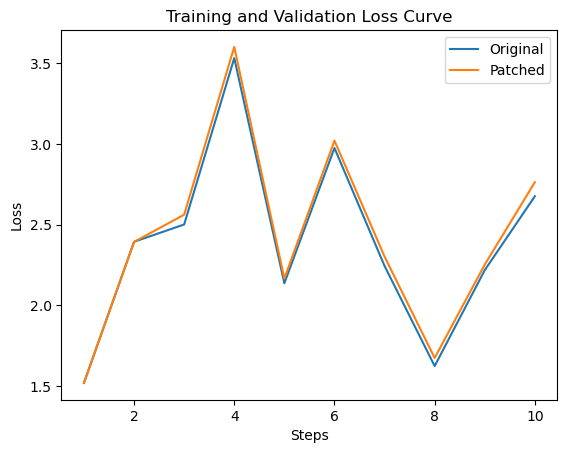

In [33]:
import matplotlib.pyplot as plt

plt.plot(original_steps, original_losses, label="Original")
plt.plot(patched_steps, patched_losses, label="Patched")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve")
plt.legend()  # Show the legend
plt.show()

We get a reasonable number of recompiles due to not using a static cache (which would also use a lot more memory and is probably not worth it).

The losses are close, though not as close as if `dynamic=False` was set for flex attention. 

This small divergence seems attributable to the tuning/selection of triton kernel parameters: commenting the `input_gen_fns` in the patches and forcing a fallback on example inputs for tuning will result in a slightly greater loss divergence, yet still bounded, stable, and correlated (same pattern, but with upward drift).